<div style="text-align: center;">
  <img src="https://drive.google.com/uc?id=1i7D7Ybh8_UY7BkWFpN_7cZ5Oga_4wkdK" width="270" height="100">
</div>

# **Chunking eficiente para RAG: calidad vs. costo computacional**


* **Luna Catalina Martínez Vásquez — A00401964**
* **Renzo Fernando Mosquera Daza — A00401681**



Comparar estrategias de segmentación de documentos —chunking de tamaño fijo, recursivo y semántico— bajo un mismo pipeline RAG, evaluando calidad de recuperación, generación de respuestas, latencia y costo computacional. El objetivo es determinar si las estrategias de chunking más complejas producen mejoras suficientes para justificar su mayor costo.

https://doi.org/10.18653/v1/2025.findings-naacl.114


|  |  |
|---|---|
| **Chunkers** | Fixed-size · Breakpoint-based Semantic · Clustering-based Semantic |
| **Evaluación** | Document Retrieval · Evidence Retrieval · Answer Generation |
| **Métricas** | Precision@k · Recall@k · F1@k · BERTScore · QA Similarity |
| **Dataset** | QASPER |

**Preparación**

In [ ]:
!pip -q install sentence-transformers spacy scikit-learn pandas numpy matplotlib bert-score requests
!python -m spacy download en_core_web_sm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 60.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import json
import math
import random
import re
import shutil
import tarfile
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Any, Iterable, List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import spacy
import torch

from bert_score import score as bertscore
from sentence_transformers import SentenceTransformer
from sklearn.cluster import DBSCAN

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo:", DEVICE)

Dispositivo: cpu


**QASPER**

Cada registro contiene `id`, `title`, `abstract`, `full_text`, `qas` y `figures_and_tables`.

In [ ]:
DATA_DIR = Path("/content/qasper_data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

ARCHIVES = {
    "train_dev": "https://qasper-dataset.s3.us-west-2.amazonaws.com/qasper-train-dev-v0.3.tgz",
    "test": "https://qasper-dataset.s3.us-west-2.amazonaws.com/qasper-test-and-evaluator-v0.3.tgz",
}

for name, url in ARCHIVES.items():
    archive_path = DATA_DIR / f"{name}.tgz"

    if not archive_path.exists():
        response = requests.get(url, stream=True, timeout=120)
        response.raise_for_status()

        with open(archive_path, "wb") as file:
            for block in response.iter_content(chunk_size=1024 * 1024):
                if block:
                    file.write(block)

    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(DATA_DIR)

SOURCE_FILES = {
    "train": next(DATA_DIR.rglob("qasper-train-v0.3.json")),
    "validation": next(DATA_DIR.rglob("qasper-dev-v0.3.json")),
    "test": next(DATA_DIR.rglob("qasper-test-v0.3.json")),
}

SPLIT_FILES = {
    "train": DATA_DIR / "qasper_train.json",
    "validation": DATA_DIR / "qasper_validation.json",
    "test": DATA_DIR / "qasper_test.json",
}

for split, source in SOURCE_FILES.items():
    if source.resolve() != SPLIT_FILES[split].resolve():
        shutil.copyfile(source, SPLIT_FILES[split])

print("\n".join(f"{split}: {path}" for split, path in SPLIT_FILES.items()))

/tmp/ipykernel_5225/4293693917.py:22: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATA_DIR)


train: /content/qasper_data/qasper_train.json
validation: /content/qasper_data/qasper_validation.json
test: /content/qasper_data/qasper_test.json


In [ ]:
def load_split(path: Path):
    with open(path, "r", encoding="utf-8") as file:
        data = json.load(file)

    rows = []

    for paper_id, paper in data.items():
        row = dict(paper)
        row["id"] = paper_id
        rows.append(row)

    return rows


qasper = {
    split: load_split(path)
    for split, path in SPLIT_FILES.items()
}

for split, rows in qasper.items():
    print(f"{split}: {len(rows)} documentos")

train: 888 documentos
validation: 281 documentos
test: 416 documentos


In [ ]:
def full_text_to_string(row: Dict[str, Any]) -> str:
    paragraphs = []

    for section in row["full_text"]:
        paragraphs.extend(section.get("paragraphs", []))

    return "\n".join(
        paragraph.strip()
        for paragraph in paragraphs
        if isinstance(paragraph, str) and paragraph.strip()
    )


def highlighted_evidence_from_qa(qa: Dict[str, Any]) -> List[str]:
    evidence = []

    for annotation in qa.get("answers", []):
        answer = annotation.get("answer", {})

        for item in answer.get("highlighted_evidence", []):
            if isinstance(item, str) and item.strip() and not item.startswith("FLOAT SELECTED"):
                evidence.append(item.strip())

    return list(dict.fromkeys(evidence))


def reference_answers_from_qa(qa: Dict[str, Any]) -> List[str]:
    references = []

    for annotation in qa.get("answers", []):
        answer = annotation.get("answer", {})

        if answer.get("unanswerable") is True:
            references.append("unanswerable")
            continue

        free_form = answer.get("free_form_answer")
        if isinstance(free_form, str) and free_form.strip():
            references.append(free_form.strip())
            continue

        spans = [
            span.strip()
            for span in answer.get("extractive_spans", [])
            if isinstance(span, str) and span.strip()
        ]

        if spans:
            references.append(" ".join(spans))
            continue

        yes_no = answer.get("yes_no")
        if isinstance(yes_no, bool):
            references.append("yes" if yes_no else "no")

    return list(dict.fromkeys(references))

**Documentos**

In [ ]:
DEMO_MODE = True
# DEMO_MODE = False

DEMO_DOCS = 30

test_ds = qasper["test"]
working_rows = test_ds[:DEMO_DOCS] if DEMO_MODE else test_ds

print("Documentos seleccionados:", len(working_rows))

Documentos seleccionados: 30


**Segmentación en oraciones**

In [ ]:
nlp = spacy.load("en_core_web_sm")
nlp.max_length = 5_000_000


def split_sentences(text: str) -> List[str]:
    return [
        sentence.text.strip()
        for sentence in nlp(text).sents
        if sentence.text.strip()
    ]


documents = {}

for row in working_rows:
    text = full_text_to_string(row)

    documents[row["id"]] = {
        "id": row["id"],
        "title": row["title"],
        "text": text,
        "sentences": split_sentences(text),
        "row": row,
    }

lengths = [len(document["sentences"]) for document in documents.values()]

print("Promedio:", round(float(np.mean(lengths)), 2))
print("Mínimo:", min(lengths))
print("Máximo:", max(lengths))

Promedio: 143.7
Mínimo: 51
Máximo: 264


**Modelo de embeddings**

In [ ]:
MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"
# MODEL_NAME = "BAAI/bge-large-en-v1.5"
# MODEL_NAME = "dunzhang/stella_en_1.5B_v5"

embedder = SentenceTransformer(
    MODEL_NAME,
    device=DEVICE,
    trust_remote_code=True,
)

print(MODEL_NAME)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

sentence-transformers/all-mpnet-base-v2


In [ ]:
def encode_texts(texts: List[str], batch_size: int = 32) -> np.ndarray:
    if not texts:
        return np.empty((0, 0), dtype=np.float32)

    return embedder.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )


sentence_embeddings = {}
_sentence_embedding_start = time.perf_counter()

for index, (doc_id, document) in enumerate(documents.items(), start=1):
    sentence_embeddings[doc_id] = encode_texts(document["sentences"])

    if index % 10 == 0 or index == len(documents):
        print(f"{index}/{len(documents)}")

SEMANTIC_SENTENCE_EMBEDDING_MS = (time.perf_counter() - _sentence_embedding_start) * 1000
print("Tiempo embeddings de oraciones (ms):", round(SEMANTIC_SENTENCE_EMBEDDING_MS, 2))


10/30
20/30
30/30


**Fixed-size Chunker**

In [ ]:
@dataclass
class Chunk:
    doc_id: str
    sentence_indices: List[int]
    text: str


def make_chunk(doc_id: str, sentences: List[str], indices: Iterable[int]) -> Chunk:
    indices = sorted(list(indices))

    return Chunk(
        doc_id=doc_id,
        sentence_indices=indices,
        text=" ".join(sentences[index] for index in indices),
    )


def fixed_size_chunker(
    doc_id: str,
    sentences: List[str],
    n_chunks: int,
    overlap: int = 0,
) -> List[Chunk]:
    n = len(sentences)

    if n == 0:
        return []

    n_chunks = max(1, min(n_chunks, n))
    boundaries = np.linspace(0, n, n_chunks + 1, dtype=int)

    chunks = []

    for index in range(n_chunks):
        start = boundaries[index]
        end = boundaries[index + 1]

        if index > 0:
            start = max(0, start - overlap)

        if end > start:
            chunks.append(make_chunk(doc_id, sentences, range(start, end)))

    return chunks

**Breakpoint-based Semantic Chunker**

In [ ]:
BREAKPOINT_GRIDS = {
    "percentile": [10, 30, 50, 70, 90],
    "std": [1, 1.5, 2, 2.5, 3],
    "interquartile": [0.5, 0.75, 1, 1.25, 1.5],
    "gradient_percentile": [10, 30, 50, 70, 90],
    "distance_absolute": [0.1, 0.2, 0.3, 0.4, 0.5],
    "gradient_absolute": [0.01, 0.05, 0.1, 0.15, 0.2],
}


def consecutive_cosine_distances(embeddings: np.ndarray) -> np.ndarray:
    if len(embeddings) < 2:
        return np.array([], dtype=float)

    cosine = np.sum(embeddings[:-1] * embeddings[1:], axis=1)
    cosine = np.clip(cosine, 0.0, 1.0)

    return 1.0 - cosine


def breakpoint_mask(
    distances: np.ndarray,
    threshold_type: str,
    amount: float,
):
    if len(distances) == 0:
        return np.array([], dtype=bool), np.nan, distances

    if threshold_type == "percentile":
        values = distances
        threshold = np.percentile(values, amount)

    elif threshold_type == "std":
        values = distances
        threshold = np.mean(values) + amount * np.std(values)

    elif threshold_type == "interquartile":
        values = distances
        q1, q3 = np.percentile(values, [25, 75])
        threshold = np.mean(values) + amount * (q3 - q1)

    elif threshold_type == "gradient_percentile":
        values = np.gradient(
            distances,
            edge_order=2 if len(distances) >= 3 else 1,
        )
        threshold = np.percentile(values, amount)

    elif threshold_type == "distance_absolute":
        values = distances
        threshold = amount

    elif threshold_type == "gradient_absolute":
        values = np.gradient(
            distances,
            edge_order=2 if len(distances) >= 3 else 1,
        )
        threshold = amount

    else:
        raise ValueError(threshold_type)

    return values > threshold, float(threshold), values


def breakpoint_chunker(
    doc_id: str,
    sentences: List[str],
    embeddings: np.ndarray,
    threshold_type: str = "percentile",
    amount: float = 70,
) -> List[Chunk]:
    n = len(sentences)

    if n == 0:
        return []

    if n == 1:
        return [make_chunk(doc_id, sentences, [0])]

    distances = consecutive_cosine_distances(embeddings)
    mask, _, _ = breakpoint_mask(distances, threshold_type, amount)
    break_after = set(np.where(mask)[0].tolist())

    chunks = []
    start = 0

    for index in range(n - 1):
        if index in break_after:
            chunks.append(make_chunk(doc_id, sentences, range(start, index + 1)))
            start = index + 1

    chunks.append(make_chunk(doc_id, sentences, range(start, n)))

    return chunks

**Clustering-based Semantic Chunker**

In [ ]:
LAMBDAS = [0, 0.25, 0.5, 0.75, 1]
N_CHUNKS_GRID = list(range(2, 11))
EPS_GRID = [0.1, 0.2, 0.3, 0.4, 0.5]
MIN_SAMPLES_GRID = [1, 2, 3, 4, 5]


def combined_distance_matrix(embeddings: np.ndarray, lam: float) -> np.ndarray:
    n = len(embeddings)

    if n == 0:
        return np.empty((0, 0))

    cosine = np.clip(embeddings @ embeddings.T, 0.0, 1.0)
    d_cos = 1.0 - cosine

    positions = np.arange(n)
    d_pos = np.abs(positions[:, None] - positions[None, :]) / max(n, 1)

    matrix = lam * d_pos + (1.0 - lam) * d_cos
    np.fill_diagonal(matrix, 0.0)

    return matrix


class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
        self.members = {index: [index] for index in range(n)}

    def find(self, value):
        while self.parent[value] != value:
            self.parent[value] = self.parent[self.parent[value]]
            value = self.parent[value]

        return value

    def union(self, first, second):
        root_first = self.find(first)
        root_second = self.find(second)

        if root_first == root_second:
            return

        if len(self.members[root_first]) < len(self.members[root_second]):
            root_first, root_second = root_second, root_first

        self.parent[root_second] = root_first
        self.members[root_first].extend(self.members[root_second])
        del self.members[root_second]

    def clusters(self):
        return [sorted(indices) for indices in self.members.values()]


def single_linkage_chunker(
    doc_id: str,
    sentences: List[str],
    embeddings: np.ndarray,
    lam: float = 0.5,
    n_chunks: int = 4,
    stopping_threshold: float = 0.5,
) -> List[Chunk]:
    n = len(sentences)

    if n == 0:
        return []

    if n == 1:
        return [make_chunk(doc_id, sentences, [0])]

    n_chunks = max(1, min(n_chunks, n))
    max_chunk_size = math.ceil(n / n_chunks)
    distances = combined_distance_matrix(embeddings, lam)

    pairs = [
        (distances[i, j], i, j)
        for i in range(n)
        for j in range(i + 1, n)
    ]
    pairs.sort(key=lambda item: item[0])

    clusters = UnionFind(n)

    for distance, first, second in pairs:
        if len(clusters.members) <= n_chunks or distance > stopping_threshold:
            break

        root_first = clusters.find(first)
        root_second = clusters.find(second)

        if root_first == root_second:
            continue

        if len(clusters.members[root_first]) + len(clusters.members[root_second]) > max_chunk_size:
            continue

        clusters.union(root_first, root_second)

    groups = clusters.clusters()
    groups.sort(key=min)

    return [make_chunk(doc_id, sentences, group) for group in groups]


def dbscan_chunker(
    doc_id: str,
    sentences: List[str],
    embeddings: np.ndarray,
    lam: float = 0.5,
    eps: float = 0.3,
    min_samples: int = 2,
) -> List[Chunk]:
    if not sentences:
        return []

    if len(sentences) == 1:
        return [make_chunk(doc_id, sentences, [0])]

    distances = combined_distance_matrix(embeddings, lam)

    labels = DBSCAN(
        eps=eps,
        min_samples=min_samples,
        metric="precomputed",
    ).fit_predict(distances)

    groups = {}
    noise_index = 0

    for index, label in enumerate(labels):
        if label == -1:
            key = ("noise", noise_index)
            noise_index += 1
        else:
            key = ("cluster", int(label))

        groups.setdefault(key, []).append(index)

    grouped_indices = [sorted(group) for group in groups.values()]
    grouped_indices.sort(key=min)

    return [make_chunk(doc_id, sentences, group) for group in grouped_indices]

**Visualización de chunks**

In [ ]:
example_doc_id = next(iter(documents))
example_document = documents[example_doc_id]

sentences = example_document["sentences"]
embeddings = sentence_embeddings[example_doc_id]

examples = {
    "Fixed-size": fixed_size_chunker(
        example_doc_id,
        sentences,
        n_chunks=4,
        overlap=0,
    ),
    "Breakpoint": breakpoint_chunker(
        example_doc_id,
        sentences,
        embeddings,
        threshold_type="percentile",
        amount=70,
    ),
    "Clustering": single_linkage_chunker(
        example_doc_id,
        sentences,
        embeddings,
        lam=0.5,
        n_chunks=4,
    ),
}


def chunks_table(chunks: List[Chunk], max_chars: int = 650):
    return pd.DataFrame([
        {
            "chunk": index,
            "oraciones": len(chunk.sentence_indices),
            "índices": chunk.sentence_indices,
            "texto": chunk.text[:max_chars] + ("..." if len(chunk.text) > max_chars else ""),
        }
        for index, chunk in enumerate(chunks, start=1)
    ])


print(example_document["title"])

for name, chunks in examples.items():
    print(f"\n{name}")
    display(chunks_table(chunks))

End-to-End Trainable Non-Collaborative Dialog System

Fixed-size


,chunk,oraciones,índices,texto
0,1,65,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",Considerable progress has been made building e...
1,2,65,"[65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 7...",budzianowski2019hello focused on collaborative...
2,3,65,"[130, 131, 132, 133, 134, 135, 136, 137, 138, ...","For example, in Figure FIGREF6, we insert a $<..."
3,4,66,"[195, 196, 197, 198, 199, 200, 201, 202, 203, ...",MISSA also has a higher task success score (1....



Breakpoint


,chunk,oraciones,índices,texto
0,1,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",Considerable progress has been made building e...
1,2,3,"[12, 13, 14]","Therefore, we need to design a system that han..."
2,3,1,[15],"However, such a method is difficult to train a..."
3,4,4,"[16, 17, 18, 19]","To tackle these problems, we propose a hierarc..."
4,5,4,"[20, 21, 22, 23]",Previous studies use template-based methods to...
...,...,...,...,...
74,75,2,"[248, 249]",We recruited two expert annotators who have li...
75,76,4,"[250, 251, 252, 253]",We observe that sentences from the attacker an...
76,77,5,"[254, 255, 256, 257, 258]",MISSA is based on the generative pre-trained t...
77,78,1,[259],"To deal with the words out of the vocabulary, ..."



Clustering


,chunk,oraciones,índices,texto
0,1,66,"[0, 2, 5, 6, 12, 13, 14, 16, 17, 18, 28, 29, 3...",Considerable progress has been made building e...
1,2,63,"[1, 3, 4, 7, 8, 9, 10, 11, 15, 19, 20, 21, 22,...",Examples of collaborative tasks include making...
2,3,66,"[24, 64, 69, 87, 94, 95, 101, 103, 107, 108, 1...",MISSA follows the TransferTransfo framework BI...
3,4,66,"[111, 112, 113, 117, 121, 123, 125, 128, 129, ...","(2) In dialog systems, multiple generated resp..."


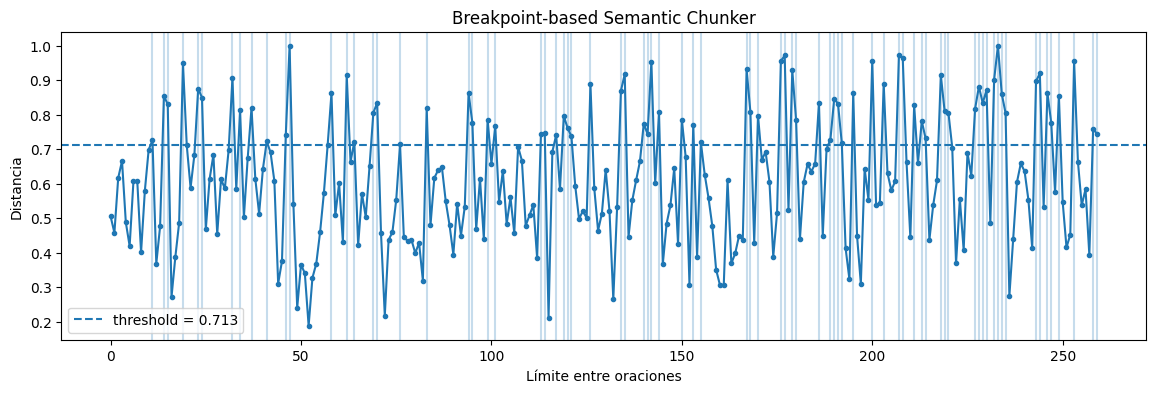

In [ ]:
distances = consecutive_cosine_distances(embeddings)
mask, threshold, values = breakpoint_mask(distances, "percentile", 70)

plt.figure(figsize=(14, 4))
plt.plot(np.arange(len(values)), values, marker="o", markersize=3)
plt.axhline(threshold, linestyle="--", label=f"threshold = {threshold:.3f}")

for index in np.where(mask)[0]:
    plt.axvline(index, alpha=0.25)

plt.title("Breakpoint-based Semantic Chunker")
plt.xlabel("Límite entre oraciones")
plt.ylabel("Distancia")
plt.legend()
plt.show()

**Preguntas**

In [ ]:
qa_rows = []

for doc_id, document in documents.items():
    for qa in document["row"].get("qas", []):
        qa_rows.append({
            "doc_id": doc_id,
            "question_id": qa.get("question_id"),
            "question": qa.get("question"),
            "evidence": highlighted_evidence_from_qa(qa),
            "reference_answers": reference_answers_from_qa(qa),
        })

qa_df = pd.DataFrame(qa_rows)

print("Preguntas:", len(qa_df))
display(qa_df.head())

Preguntas: 104


,doc_id,question_id,question,evidence,reference_answers
0,1911.10742,397a1e851aab41c455c2b284f5e4947500d797f0,How big is the ANTISCAM dataset?,[We posted a role-playing task on the Amazon M...,"[3,044 sentences in 100 dialogs, 220 human-hum..."
1,1911.10742,cc8b4ed3985f9bfbe1b5d7761b31d9bd6a965444,How is intent annotated?,"[dataset, To enrich available non-collaborativ...",[using a role-playing task on the Amazon Mecha...
2,1911.10742,f7662b11e87c1e051e13799413f3db459ac3e19c,What are the baselines outperformed by this work?,[We compare MISSA mainly with two baseline mod...,"[TransferTransfo and Hybrid, TransferTransfo h..."
3,1911.10742,b584739622d0c53830e60430b13fd3ae6ff43669,What are the evaluation metrics and criteria u...,[Experiments ::: Automatic Evaluation Metrics\...,[Perplexity Response-Intent Prediction (RIP) R...
4,1904.09131,2849c2944c47cf1de62b539c5d3c396a3e8d283a,What is the accuracy of this model compared to...,[We illustrate these differences by building a...,"[unanswerable, The model improves the state of..."


**Retrieval**

In [ ]:
LAST_CORPUS_PROFILE = {}


def build_chunk_corpus(strategy: str, **params):
    global LAST_CORPUS_PROFILE
    chunks = []
    chunking_start = time.perf_counter()

    for doc_id, document in documents.items():
        sentences = document["sentences"]
        embeddings = sentence_embeddings[doc_id]

        if strategy == "fixed":
            current = fixed_size_chunker(doc_id, sentences, **params)

        elif strategy == "breakpoint":
            current = breakpoint_chunker(doc_id, sentences, embeddings, **params)

        elif strategy == "single_linkage":
            current = single_linkage_chunker(doc_id, sentences, embeddings, **params)

        elif strategy == "dbscan":
            current = dbscan_chunker(doc_id, sentences, embeddings, **params)

        else:
            raise ValueError(strategy)

        chunks.extend(current)

    chunking_ms = (time.perf_counter() - chunking_start) * 1000
    indexing_start = time.perf_counter()
    chunk_embeddings = encode_texts([chunk.text for chunk in chunks])
    indexing_ms = (time.perf_counter() - indexing_start) * 1000

    LAST_CORPUS_PROFILE = {
        "chunking_ms": chunking_ms,
        "indexing_ms": indexing_ms,
        "build_and_index_ms": chunking_ms + indexing_ms,
    }

    return chunks, chunk_embeddings


def retrieve_top_k(
    question: str,
    chunks: List[Chunk],
    chunk_embeddings: np.ndarray,
    k: int,
):
    query_embedding = encode_texts([question])[0]
    scores = chunk_embeddings @ query_embedding
    indices = np.argsort(-scores)[:k]

    return [(chunks[index], float(scores[index])) for index in indices]


**Document Retrieval**

In [ ]:
K_VALUES = [1, 3, 5, 10]


def prf1(retrieved: set, relevant: set):
    precision = len(retrieved & relevant) / len(retrieved) if retrieved else 0.0
    recall = len(retrieved & relevant) / len(relevant) if relevant else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0

    return precision, recall, f1


def evaluate_document_retrieval(
    chunks,
    chunk_embeddings,
    questions,
    k_values=K_VALUES,
    max_queries=None,
):
    evaluation = questions.copy()

    if max_queries is not None and len(evaluation) > max_queries:
        evaluation = evaluation.sample(max_queries, random_state=SEED)

    rows = []

    for _, item in evaluation.iterrows():
        relevant_docs = {item["doc_id"]}

        for k in k_values:
            retrieved = retrieve_top_k(
                item["question"],
                chunks,
                chunk_embeddings,
                k,
            )

            retrieved_docs = {chunk.doc_id for chunk, _ in retrieved}
            precision, recall, f1 = prf1(retrieved_docs, relevant_docs)

            rows.append({
                "question_id": item["question_id"],
                "k": k,
                "precision": precision,
                "recall": recall,
                "f1": f1,
            })

    return pd.DataFrame(rows)

**Evidence Retrieval**

In [ ]:
def normalize_text(text: str) -> str:
    return re.sub(r"\s+", " ", text.lower().strip())


def retrieved_sentence_set(chunks: List[Chunk]) -> set:
    sentences = set()

    for chunk in chunks:
        source = documents[chunk.doc_id]["sentences"]

        for index in chunk.sentence_indices:
            sentences.add(normalize_text(source[index]))

    return sentences


def evidence_sentence_set(evidence: List[str]) -> set:
    sentences = set()

    for item in evidence:
        for sentence in split_sentences(item):
            sentences.add(normalize_text(sentence))

    return sentences


def evaluate_evidence_retrieval(
    chunks,
    chunk_embeddings,
    questions,
    k_values=K_VALUES,
    max_queries=None,
):
    evaluation = questions[questions["evidence"].map(len) > 0].copy()

    if max_queries is not None and len(evaluation) > max_queries:
        evaluation = evaluation.sample(max_queries, random_state=SEED)

    rows = []

    for _, item in evaluation.iterrows():
        relevant = evidence_sentence_set(item["evidence"])

        for k in k_values:
            retrieved = retrieve_top_k(
                item["question"],
                chunks,
                chunk_embeddings,
                k,
            )

            retrieved_chunks = [chunk for chunk, _ in retrieved]
            retrieved_sentences = retrieved_sentence_set(retrieved_chunks)
            precision, recall, f1 = prf1(retrieved_sentences, relevant)

            rows.append({
                "question_id": item["question_id"],
                "k": k,
                "precision": precision,
                "recall": recall,
                "f1": f1,
            })

    return pd.DataFrame(rows)

**Comparación inicial**

In [ ]:
EXPERIMENTS = {
    "Fixed-size": {
        "strategy": "fixed",
        "params": {"n_chunks": 4, "overlap": 0},
    },
    "Breakpoint": {
        "strategy": "breakpoint",
        "params": {"threshold_type": "percentile", "amount": 70},
    },
    "Clustering": {
        "strategy": "single_linkage",
        "params": {"lam": 0.5, "n_chunks": 4},
    },
}

MAX_EVAL_QUERIES = 30 if DEMO_MODE else 100

experiment_outputs = {}

for name, experiment in EXPERIMENTS.items():
    print(name)

    chunks, chunk_embeddings = build_chunk_corpus(
        experiment["strategy"],
        **experiment["params"],
    )

    experiment_outputs[name] = {
        "chunks": chunks,
        "embeddings": chunk_embeddings,
        "profile": dict(LAST_CORPUS_PROFILE),
        "document": evaluate_document_retrieval(
            chunks,
            chunk_embeddings,
            qa_df,
            max_queries=MAX_EVAL_QUERIES,
        ),
        "evidence": evaluate_evidence_retrieval(
            chunks,
            chunk_embeddings,
            qa_df,
            max_queries=MAX_EVAL_QUERIES,
        ),
    }


Fixed-size
Breakpoint
Clustering


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
summary_rows = []

for name, output in experiment_outputs.items():
    for task in ["document", "evidence"]:
        metrics = (
            output[task]
            .groupby("k")[["precision", "recall", "f1"]]
            .mean()
            .reset_index()
        )

        for _, row in metrics.iterrows():
            summary_rows.append({
                "chunker": name,
                "task": task,
                "k": int(row["k"]),
                "precision": row["precision"],
                "recall": row["recall"],
                "f1": row["f1"],
            })

summary = pd.DataFrame(summary_rows)
display(summary)

,chunker,task,k,precision,recall,f1
0,Fixed-size,document,1,0.300000,0.300000,0.300000
1,Fixed-size,document,3,0.244444,0.366667,0.283333
2,Fixed-size,document,5,0.140000,0.366667,0.200000
3,Fixed-size,document,10,0.079722,0.433333,0.133968
4,Fixed-size,evidence,1,0.043565,0.128687,0.061326
5,Fixed-size,evidence,3,0.025208,0.261448,0.044582
6,Fixed-size,evidence,5,0.019139,0.305892,0.035261
7,Fixed-size,evidence,10,0.009813,0.312241,0.018780
8,Breakpoint,document,1,0.400000,0.400000,0.400000
9,Breakpoint,document,3,0.300000,0.433333,0.338889


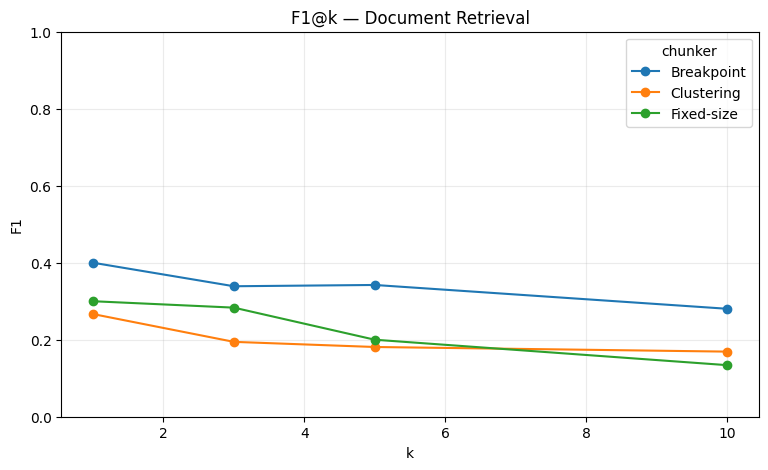

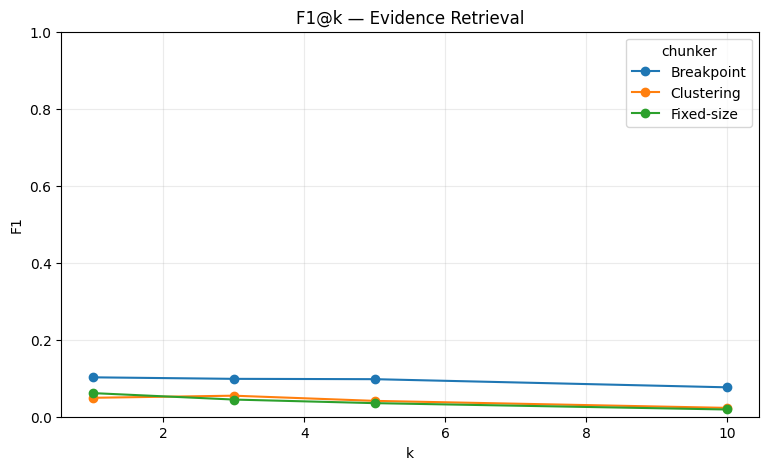

In [ ]:
for task in ["document", "evidence"]:
    plot_data = (
        summary[summary["task"] == task]
        .pivot(index="k", columns="chunker", values="f1")
    )

    plot_data.plot(marker="o", figsize=(9, 5))

    plt.title(f"F1@k — {task.title()} Retrieval")
    plt.xlabel("k")
    plt.ylabel("F1")
    plt.ylim(0, 1)
    plt.grid(alpha=0.25)
    plt.show()

**Hiperparámetros**

In [ ]:
fixed_configs = [
    {"n_chunks": n_chunks, "overlap": overlap}
    for n_chunks in range(2, 11)
    for overlap in [0, 1]
]

breakpoint_configs = [
    {"threshold_type": threshold_type, "amount": amount}
    for threshold_type, values in BREAKPOINT_GRIDS.items()
    for amount in values
]

single_linkage_configs = [
    {"lam": lam, "n_chunks": n_chunks}
    for lam in LAMBDAS
    for n_chunks in N_CHUNKS_GRID
]

dbscan_configs = [
    {"lam": lam, "eps": eps, "min_samples": min_samples}
    for lam in LAMBDAS
    for eps in EPS_GRID
    for min_samples in MIN_SAMPLES_GRID
]

print("Fixed-size:", len(fixed_configs))
print("Breakpoint:", len(breakpoint_configs))
print("Single-linkage:", len(single_linkage_configs))
print("DBSCAN:", len(dbscan_configs))

Fixed-size: 18
Breakpoint: 30
Single-linkage: 45
DBSCAN: 125


In [ ]:
def evaluate_configuration(
    strategy,
    params,
    task="evidence",
    max_queries=None,
):
    chunks, chunk_embeddings = build_chunk_corpus(strategy, **params)

    if task == "document":
        result = evaluate_document_retrieval(
            chunks,
            chunk_embeddings,
            qa_df,
            max_queries=max_queries,
        )
    else:
        result = evaluate_evidence_retrieval(
            chunks,
            chunk_embeddings,
            qa_df,
            max_queries=max_queries,
        )

    metrics = result.groupby("k")[["precision", "recall", "f1"]].mean()

    return {
        "avg_f1": float(metrics["f1"].mean()),
        "n_chunks": len(chunks),
    }


def run_grid(
    strategy,
    configs,
    task="evidence",
    max_queries=None,
):
    rows = []

    for index, params in enumerate(configs, start=1):
        print(f"{index}/{len(configs)}", params)

        result = evaluate_configuration(
            strategy,
            params,
            task=task,
            max_queries=max_queries,
        )

        rows.append({
            **params,
            **result,
        })

    return pd.DataFrame(rows).sort_values("avg_f1", ascending=False)

In [ ]:
RUN_FULL_GRID = False
# RUN_FULL_GRID = True

if RUN_FULL_GRID:
    fixed_grid = run_grid(
        "fixed",
        fixed_configs,
        task="evidence",
        max_queries=100,
    )

    breakpoint_grid = run_grid(
        "breakpoint",
        breakpoint_configs,
        task="evidence",
        max_queries=100,
    )

    single_linkage_grid = run_grid(
        "single_linkage",
        single_linkage_configs,
        task="evidence",
        max_queries=100,
    )

    dbscan_grid = run_grid(
        "dbscan",
        dbscan_configs,
        task="evidence",
        max_queries=100,
    )

**Visualización de hiperparámetros**

,n_chunks,precision,recall,f1
0,2,0.009056,0.361111,0.017551
1,3,0.014511,0.367705,0.027600
2,4,0.019727,0.386111,0.036978
3,5,0.017280,0.313611,0.032161
4,6,0.024163,0.334841,0.043992
5,7,0.028343,0.401719,0.051864
6,8,0.032494,0.344484,0.058093
7,9,0.035236,0.318220,0.061479
8,10,0.032006,0.309643,0.056439


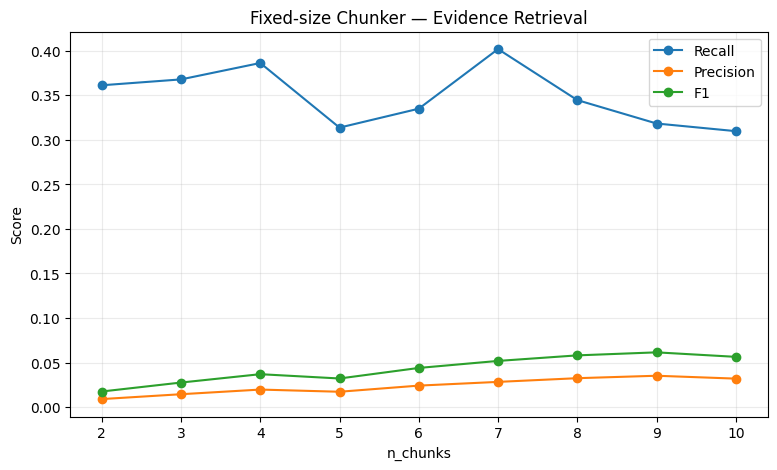

In [ ]:
def sweep_parameter(
    strategy,
    parameter,
    values,
    fixed_params,
    task="evidence",
    k=5,
    max_queries=None,
):
    rows = []

    for value in values:
        params = dict(fixed_params)
        params[parameter] = value

        chunks, chunk_embeddings = build_chunk_corpus(strategy, **params)

        if task == "document":
            result = evaluate_document_retrieval(
                chunks,
                chunk_embeddings,
                qa_df,
                k_values=[k],
                max_queries=max_queries,
            )
        else:
            result = evaluate_evidence_retrieval(
                chunks,
                chunk_embeddings,
                qa_df,
                k_values=[k],
                max_queries=max_queries,
            )

        rows.append({
            parameter: value,
            "precision": result["precision"].mean(),
            "recall": result["recall"].mean(),
            "f1": result["f1"].mean(),
        })

    return pd.DataFrame(rows)


sweep = sweep_parameter(
    "fixed",
    "n_chunks",
    range(2, 11),
    {"overlap": 0},
    task="evidence",
    k=5,
    max_queries=20 if DEMO_MODE else 100,
)

display(sweep)

plt.figure(figsize=(9, 5))
plt.plot(sweep["n_chunks"], sweep["recall"], marker="o", label="Recall")
plt.plot(sweep["n_chunks"], sweep["precision"], marker="o", label="Precision")
plt.plot(sweep["n_chunks"], sweep["f1"], marker="o", label="F1")
plt.xlabel("n_chunks")
plt.ylabel("Score")
plt.title("Fixed-size Chunker — Evidence Retrieval")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

**Answer Generation**

In [ ]:
def prepare_generation_inputs(
    chunks,
    chunk_embeddings,
    questions,
    max_queries=20,
):
    evaluation = questions[questions["reference_answers"].map(len) > 0].copy()

    if max_queries is not None and len(evaluation) > max_queries:
        evaluation = evaluation.sample(max_queries, random_state=SEED)

    rows = []

    for _, item in evaluation.iterrows():
        retrieved = retrieve_top_k(
            item["question"],
            chunks,
            chunk_embeddings,
            k=5,
        )

        rows.append({
            "question_id": item["question_id"],
            "question": item["question"],
            "top5_chunks": [chunk.text for chunk, _ in retrieved],
            "reference_answers": item["reference_answers"],
        })

    return pd.DataFrame(rows)


generation_inputs = prepare_generation_inputs(
    experiment_outputs["Fixed-size"]["chunks"],
    experiment_outputs["Fixed-size"]["embeddings"],
    qa_df,
    max_queries=10 if DEMO_MODE else 100,
)

display(generation_inputs.head())

,question_id,question,top5_chunks,reference_answers
0,230ff86b7b90b87c33c53014bb1e9c582dfc107f,What morphological typologies are considered?,"[Finally, the label distribution is calculated...","[agglutinative and fusional languages, aggluti..."
1,04914917d01c9cd8718cd551dc253eb3827915d8,Did the system perform well on low-resource la...,[While zero-shot transfer is a good measure of...,[unanswerable]
2,3de3a083b8ba3086792d38ae9667e095070f7f37,How many languages are in the dataset?,[While zero-shot transfer is a good measure of...,"[2, 2 (Spanish and English)]"
3,d36a6447bfe58204e0d29f9213d84be04d875624,what dataset was used?,"[In our experiment, we take the batch size as ...",[two types of simultaneous speech EEG recordin...
4,d9e7633004ed1bc1ee45be58409bcc1fa6db59b2,What languages does the new dataset contain?,[While zero-shot transfer is a good measure of...,"[English French Arabic, English, French, and A..."


**BERTScore y QA Similarity**

In [ ]:
def evaluate_generated_answers(generated_answers: pd.DataFrame):
    rows = []

    for _, item in generated_answers.iterrows():
        references = item["reference_answers"]

        if not references:
            continue

        candidates = [item["generated_answer"]] * len(references)

        _, _, f1 = bertscore(
            candidates,
            references,
            model_type="microsoft/deberta-xlarge-mnli",
            lang="en",
            verbose=False,
        )

        question_embedding = encode_texts([item["question"]])[0]
        answer_embedding = encode_texts([item["generated_answer"]])[0]
        qa_similarity = float(question_embedding @ answer_embedding)

        rows.append({
            "question_id": item["question_id"],
            "bertscore": float(f1.max().item()),
            "qa_similarity": qa_similarity,
        })

    return pd.DataFrame(rows)

**Resultados**

In [ ]:
RESULTS_DIR = Path("/content/results_chunking")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def token_lengths(texts: List[str], max_length: int, batch_size: int = 128):
    raw_lengths = []

    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        encoded = embedder.tokenizer(
            batch,
            add_special_tokens=True,
            truncation=False,
            padding=False,
        )
        raw_lengths.extend(len(ids) for ids in encoded["input_ids"])

    effective_lengths = [min(length, max_length) for length in raw_lengths]
    return raw_lengths, effective_lengths


def summarize_token_lengths(raw_lengths, effective_lengths, max_length):
    if not raw_lengths:
        return {
            "raw_tokens": 0,
            "effective_tokens": 0,
            "avg_raw_tokens": 0.0,
            "avg_effective_tokens": 0.0,
            "p95_raw_tokens": 0.0,
            "truncated_items": 0,
        }

    return {
        "raw_tokens": int(sum(raw_lengths)),
        "effective_tokens": int(sum(effective_lengths)),
        "avg_raw_tokens": float(np.mean(raw_lengths)),
        "avg_effective_tokens": float(np.mean(effective_lengths)),
        "p95_raw_tokens": float(np.percentile(raw_lengths, 95)),
        "truncated_items": int(sum(length > max_length for length in raw_lengths)),
    }


def serializable_chunk(chunk: Chunk, raw_tokens: int, effective_tokens: int, number: int):
    return {
        "chunk": number,
        "sentence_indices": [int(index) for index in chunk.sentence_indices],
        "sentence_count": len(chunk.sentence_indices),
        "raw_tokens": int(raw_tokens),
        "effective_tokens": int(effective_tokens),
        "text": chunk.text,
    }


MAX_SEQUENCE_LENGTH = int(getattr(embedder, "max_seq_length", 384) or 384)
all_sentences = [
    sentence
    for document in documents.values()
    for sentence in document["sentences"]
]
sentence_raw_tokens, sentence_effective_tokens = token_lengths(
    all_sentences,
    MAX_SEQUENCE_LENGTH,
)
sentence_token_summary = summarize_token_lengths(
    sentence_raw_tokens,
    sentence_effective_tokens,
    MAX_SEQUENCE_LENGTH,
)

strategy_rows = []
strategy_token_lengths = {}
evidence_sample = qa_df[qa_df["evidence"].map(len) > 0].copy()
if len(evidence_sample) > MAX_EVAL_QUERIES:
    evidence_sample = evidence_sample.sample(MAX_EVAL_QUERIES, random_state=SEED)
evidence_query_embeddings = encode_texts(evidence_sample["question"].tolist()) if len(evidence_sample) else np.empty((0, 0))

for name, output in experiment_outputs.items():
    chunks = output["chunks"]
    chunk_texts = [chunk.text for chunk in chunks]
    raw_lengths, effective_lengths = token_lengths(chunk_texts, MAX_SEQUENCE_LENGTH)
    chunk_summary = summarize_token_lengths(raw_lengths, effective_lengths, MAX_SEQUENCE_LENGTH)
    strategy_token_lengths[name] = {
        "raw": raw_lengths,
        "effective": effective_lengths,
    }

    semantic_strategy = name in {"Breakpoint", "Clustering"}
    semantic_tokens = sentence_token_summary["effective_tokens"] if semantic_strategy else 0
    semantic_ms = SEMANTIC_SENTENCE_EMBEDDING_MS if semantic_strategy else 0.0

    context_token_totals = []
    for query_embedding in evidence_query_embeddings:
        scores = output["embeddings"] @ query_embedding
        indices = np.argsort(-scores)[:5]
        context_token_totals.append(sum(effective_lengths[index] for index in indices))

    profile = output.get("profile", {})
    total_preprocessing_ms = (
        semantic_ms
        + float(profile.get("chunking_ms", 0.0))
        + float(profile.get("indexing_ms", 0.0))
    )

    strategy_rows.append({
        "name": name,
        "n_chunks": len(chunks),
        "avg_sentences_per_chunk": float(np.mean([
            len(chunk.sentence_indices)
            for chunk in chunks
        ])) if chunks else 0.0,
        "semantic_prep_ms": float(semantic_ms),
        "chunking_ms": float(profile.get("chunking_ms", 0.0)),
        "indexing_ms": float(profile.get("indexing_ms", 0.0)),
        "total_preprocessing_ms": float(total_preprocessing_ms),
        "semantic_prep_effective_tokens": int(semantic_tokens),
        "chunk_index_raw_tokens": int(chunk_summary["raw_tokens"]),
        "chunk_index_effective_tokens": int(chunk_summary["effective_tokens"]),
        "total_embedding_effective_tokens": int(
            semantic_tokens + chunk_summary["effective_tokens"]
        ),
        "avg_raw_tokens_per_chunk": float(chunk_summary["avg_raw_tokens"]),
        "avg_effective_tokens_per_chunk": float(chunk_summary["avg_effective_tokens"]),
        "p95_raw_tokens_per_chunk": float(chunk_summary["p95_raw_tokens"]),
        "truncated_chunks": int(chunk_summary["truncated_items"]),
        "avg_retrieved_context_tokens_at_5": float(np.mean(context_token_totals)) if context_token_totals else 0.0,
    })

example_doc_id = next(iter(documents))
example_document = documents[example_doc_id]
example_sentences = example_document["sentences"]
example_embeddings = sentence_embeddings[example_doc_id]
example_distances = consecutive_cosine_distances(example_embeddings)
example_mask, example_threshold, example_values = breakpoint_mask(
    example_distances,
    "percentile",
    70,
)

visualization = {
    "mode": "qasper_run",
    "title": example_document["title"],
    "doc_id": example_doc_id,
    "sentences": example_sentences,
    "breakpoint": {
        "threshold": float(example_threshold) if not np.isnan(example_threshold) else None,
        "distances": [float(value) for value in example_values],
        "break_after": [int(value) for value in np.where(example_mask)[0]],
    },
    "strategies": {},
}

for name, output in experiment_outputs.items():
    rows = []
    raw_lengths = strategy_token_lengths[name]["raw"]
    effective_lengths = strategy_token_lengths[name]["effective"]

    for global_index, chunk in enumerate(output["chunks"]):
        if chunk.doc_id != example_doc_id:
            continue

        rows.append(serializable_chunk(
            chunk,
            raw_lengths[global_index],
            effective_lengths[global_index],
            len(rows) + 1,
        ))

    visualization["strategies"][name] = rows

retrieval_example = None
evidence_questions = qa_df[qa_df["evidence"].map(len) > 0].copy()

if not evidence_questions.empty:
    item = evidence_questions.sample(1, random_state=SEED).iloc[0]
    example_query_embedding = encode_texts([item["question"]])[0]
    retrieval_example = {
        "question": item["question"],
        "document_title": documents[item["doc_id"]]["title"],
        "gold_evidence": item["evidence"],
        "strategies": {},
    }

    for name, output in experiment_outputs.items():
        scores = output["embeddings"] @ example_query_embedding
        indices = np.argsort(-scores)[:3]
        retrieval_example["strategies"][name] = [
            {
                "rank": rank,
                "score": float(scores[index]),
                "doc_id": output["chunks"][index].doc_id,
                "sentence_indices": [int(value) for value in output["chunks"][index].sentence_indices],
                "text": output["chunks"][index].text,
            }
            for rank, index in enumerate(indices, start=1)
        ]

metrics_records = json.loads(summary.to_json(orient="records"))

payload = {
    "schema_version": 2,
    "source": {
        "status": "complete",
        "mode": "colab_run",
        "generated_at": time.strftime("%Y-%m-%dT%H:%M:%S"),
        "basis": "RAG_Chunking_Paper.ipynb",
        "dataset": "QASPER",
        "seed": SEED,
        "demo_mode": bool(DEMO_MODE),
    },
    "run": {
        "model": MODEL_NAME,
        "device": DEVICE,
        "documents": len(documents),
        "questions_total": len(qa_df),
        "evaluation_questions_per_task": int(MAX_EVAL_QUERIES),
        "sentences": len(all_sentences),
        "max_sequence_length": MAX_SEQUENCE_LENGTH,
        "semantic_sentence_embedding_ms": float(SEMANTIC_SENTENCE_EMBEDDING_MS),
        "semantic_sentence_effective_tokens": int(sentence_token_summary["effective_tokens"]),
    },
    "metrics": metrics_records,
    "strategies": strategy_rows,
    "visualization": visualization,
    "retrieval_example": retrieval_example,
    "answer_generation": {
        "status": "inputs_only",
        "message": "El notebook prepara entradas de generación y funciones de evaluación, pero esta exportación no inventa respuestas generadas que no hayan sido ejecutadas.",
    },
    "methodology": {
        "quality_metric": "F1@5 de Evidence Retrieval como lectura principal, manteniendo k = 1, 3, 5 y 10.",
        "cost_metric": "Tiempo de segmentación, embeddings de chunks y, para métodos semánticos, embeddings de oraciones.",
        "token_metric": "Tokens efectivos procesados por el modelo de embeddings en segmentación semántica e indexación de chunks; además se reporta el contexto promedio recuperado en top-5.",
        "timing_note": "Los tiempos sirven para comparar estrategias dentro de esta misma corrida y hardware; no son latencias universales.",
    },
}

results_json_path = RESULTS_DIR / "results.json"
metrics_csv_path = RESULTS_DIR / "metrics.csv"
results_js_path = RESULTS_DIR / "results-data.js"

results_json_path.write_text(
    json.dumps(payload, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
summary.to_csv(metrics_csv_path, index=False)
results_js_path.write_text(
    "window.RAG_RESULTS = "
    + json.dumps(payload, ensure_ascii=False, separators=(",", ":"))
    + ";\n",
    encoding="utf-8",
)

generation_inputs.to_json(
    RESULTS_DIR / "generation_inputs.jsonl",
    orient="records",
    lines=True,
    force_ascii=False,
)

archive_path = shutil.make_archive(
    "/content/resultados_chunking_para_web",
    "zip",
    root_dir=RESULTS_DIR,
)

DRIVE_ROOT = Path("/content/drive/MyDrive")
if DRIVE_ROOT.exists():
    drive_results = DRIVE_ROOT / "chunking_rag_resultados"
    drive_results.mkdir(parents=True, exist_ok=True)
    for file_path in RESULTS_DIR.iterdir():
        if file_path.is_file():
            shutil.copy2(file_path, drive_results / file_path.name)
    shutil.copy2(archive_path, drive_results / Path(archive_path).name)
    print("Copia en Drive:", drive_results)

print("Resultados listos para la landing:")
print("-", results_json_path)
print("-", metrics_csv_path)
print("-", results_js_path)
print("-", archive_path)
print("Para actualizar la web, reemplaza data/results.json y assets/js/results-data.js con estos archivos.")


/content/results_chunking
